In [2]:
#!/usr/bin/env python3
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

# ---------------------------
# ustawienia stanów i akcji + mapy
# ---------------------------
STATES = [1,2,3,4,5,6,7]
ACTIONS = [0,1,2,3]
S2I = {s:i for i,s in enumerate(STATES)}
A2I = {a:i for i,a in enumerate(ACTIONS)}

# ---------------------------
# środowisko (funkcja step)
# ---------------------------
def step(state: int, action: int) -> Tuple[int, float]:
    if state == 1:
        reward = 20 * action if random.random() < 0.4 else -10 * action
        next_state = 2 if action in [2, 3] else 3
    elif state == 2:
        reward = 30 * action if random.random() < 0.4 else -25 * action
        next_state = 4 if action in [2, 3] else 5
    elif state == 3:
        reward = 30 * action if random.random() < 0.3 else -15 * action
        next_state = 6 if action in [2, 3] else 7
    elif state == 4:
        reward = 50 if random.random() < 0.8 else -15
        next_state = 1
    elif state == 5:
        reward = 15 if random.random() < 0.3 else -10
        next_state = 1
    elif state == 6:
        reward = 30 if random.random() < 0.8 else -10
        next_state = 1
    elif state == 7:
        reward = 20 if random.random() < 0.4 else -20
        next_state = 1
    else:
        raise ValueError(f"Nieznany stan: {state}")
    return int(next_state), float(reward)

In [3]:
import random
from typing import Tuple

def step_low_variance(state: int, action: int) -> Tuple[int, float]:
    """
    Alternatywne środowisko: mniejsza wariancja dla 'bezpiecznych' trajektorii.
    - akcje 2,3 traktujemy jako 'ryzykowne' (z mniejszym p sukcesu i większymi wahanami)
    - akcje 0,1 traktujemy jako 'bezpieczne' (większe p sukcesu, mniejsze porażki)
    """
    if state == 1:
        if action in [2, 3]:
            # ryzykowna gałąź (bez zmian w stosunku do oryginału)
            p = 0.4
            r_pos = 20 * action
            r_neg = -10 * action
            next_state = 2
        else:
            # mniej-risk: wyższe p sukcesu, mniejsze straty
            p = 0.8
            r_pos = 10 * action
            r_neg = -2 * action
            next_state = 3
        reward = r_pos if random.random() < p else r_neg

    elif state == 2:
        if action in [2, 3]:
            p = 0.4
            r_pos = 30 * action
            r_neg = -25 * action
            next_state = 4
        else:
            # jeśli w stanie 2 wybierzemy 'safe' akcję -> umiarkowany, pewniejszy wynik
            p = 0.6
            r_pos = 20 * action
            r_neg = -5 * action
            next_state = 5
        reward = r_pos if random.random() < p else r_neg

    elif state == 3:
        if action in [2, 3]:
            p = 0.3
            r_pos = 30 * action
            r_neg = -15 * action
            next_state = 6
        else:
            # mniej ryzykowna gałąź z niską wariancją
            p = 0.85
            r_pos = 12 * action
            r_neg = -3 * action
            next_state = 7
        reward = r_pos if random.random() < p else r_neg

    elif state == 4:
        p = 0.8
        r_pos = 50
        r_neg = -15
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 5:
        p = 0.9
        r_pos = 15
        r_neg = -5
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 6:
        p = 0.8
        r_pos = 30
        r_neg = -10
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    elif state == 7:
        p = 0.85
        r_pos = 12
        r_neg = -6
        reward = r_pos if random.random() < p else r_neg
        next_state = 1

    else:
        raise ValueError(f"Nieznany stan: {state}")

    return int(next_state), float(reward)


In [17]:
import numpy as np
import math

def train_q_learning_risk(
    num_episodes=1000,
    gamma=0.99,
    seed=0,
    verbose_every=100,
    # eksploracja
    eps_start=0.5,
    eps_end=0.05,
    eps_decay_frac=0.5,
    min_alpha=0.0,
    bonus_beta=0.0,
    optimistic_q=None,
    # opcja: preferowanie najmniej odwiedzanych akcji przy exploitation
    p_least_visited=0.25,
    # parametry risk-sensitive
    k1=1.0, l1=1.0, k2=1.0, l2=1.0,
    theta=0.1,
    rs_mode='entropic_RA'   # 'u', 'entropic_RA', 'entropic_RS' , 'neutral'
):
    """
    Tabularny Q-learning z możliwością testowania różnych transformacji TD:
      - 'u' : asymmetric power utility (k1,l1,k2,l2)
      - 'entropic_RA' : 1 - exp(-theta * x)
      - 'entropic_RS' : exp(theta * x)

    Uwaga: funkcja zakłada istnienie w otoczeniu zmiennych/globali:
      STATES, ACTIONS, S2I oraz funkcji step(state, action) -> (next_state, reward)

    Zwraca: q, counts, episode_rewards
    """

    rng = np.random.default_rng(seed)

    S = len(STATES)
    A = len(ACTIONS)

    # inicjalizacja Q
    if optimistic_q is None:
        q = np.zeros((S, A))
    else:
        q = np.full((S, A), optimistic_q)

    counts = np.zeros((S, A), dtype=int)
    episode_rewards = []

    def epsilon_for_episode(ep_idx):
        decay_episodes = max(1, int(eps_decay_frac * num_episodes))
        if ep_idx >= decay_episodes:
            return eps_end
        frac = ep_idx / decay_episodes
        return eps_start + frac * (eps_end - eps_start)

    # funkcja u (asymetryczna moc)
    def u(x, k1_local=k1, l1_local=l1, k2_local=k2, l2_local=l2):
        if x >= 0.0:
            return k1_local * (x ** l1_local)
        else:
            return -k2_local * ((-x) ** l2_local)

    # entropijne warianty
    def entropic_RA(x, theta_local=theta):
        return 1.0 - math.exp(- theta_local * x)

    def entropic_RS(x, theta_local=theta):
        return math.exp(theta_local * x)

    def identity(x):
        return x

    # wybierz transformację TD
    if rs_mode == 'u':
        transform = u
    elif rs_mode == 'entropic_RS':
        transform = entropic_RS
    elif rs_mode == 'entropic_RA':
        transform = entropic_RA
    else:
        transform = identity 

    for ep in range(num_episodes):
        state = rng.choice(STATES)
        total_reward = 0.0
        eps = epsilon_for_episode(ep)

        while True:
            s_i = S2I[state]

            # wybór akcji: eps-greedy + opcjonalne preferowanie najmniej odwiedzanej akcji
            if rng.random() < eps:
                a_i = int(rng.integers(0, A))
            else:
                if (p_least_visited is not None) and (rng.random() < p_least_visited):
                    minc = np.min(counts[s_i, :])
                    candidates = np.flatnonzero(counts[s_i, :] == minc)
                    a_i = int(rng.choice(candidates))
                else:
                    vals = q[s_i, :]
                    candidates = np.flatnonzero(vals == vals.max())
                    a_i = int(rng.choice(candidates))

            action = ACTIONS[a_i]

            next_state, reward = step_low_variance(state, action)    #opcjonalnie step_low_variance / step
            total_reward += reward
            ns_i = S2I[next_state]

            # aktualizacja liczników i kroku uczenia
            counts[s_i, a_i] += 1
            Nt = counts[s_i, a_i]

            alpha = 1.0 / Nt
            if min_alpha and (min_alpha > 0.0):
                alpha = max(alpha, min_alpha)

            counts_before = max(Nt - 1, 0)
            bonus = (bonus_beta / math.sqrt(counts_before + 1)) if (bonus_beta and bonus_beta > 0.0) else 0.0

            done = (next_state == 1)  # zachowano Twoją oryginalną logikę; rozważ użycie env.done jeśli dostępne
            if done:
                target = reward + bonus
            else:
                target = reward + bonus + gamma * np.max(q[ns_i, :])

            td_error = target - q[s_i, a_i]
            transformed_td = transform(td_error)
            q[s_i, a_i] = q[s_i, a_i] + alpha * transformed_td

            state = next_state
            if done:
                break

        episode_rewards.append(total_reward)

        if verbose_every and (((ep + 1) % verbose_every == 0) or ep == 0 or ep == num_episodes - 1):
            last_n = min(len(episode_rewards), verbose_every)
            avg_last = np.mean(episode_rewards[-last_n:])
            #print(f"[seed {seed}] Episode {ep+1}/{num_episodes} eps={eps:.3f} avg_reward(last {last_n}): {avg_last:.3f}")

    return q, counts, episode_rewards



=== FINAL TRAINING ===

=== TRAINING STATS ===
n_episodes: 2000
mean: 20.8
median: 15.0
std: 26.0
min: -95.0
max: 140.0

=== FINAL Q ===
[[   5.2    6.9    2.2   -6.8]
 [   5.3    7.4  -19.4 -169.7]
 [   5.2    7.4   -4.2  -15.7]
 [   7.2    6.7    6.5    4. ]
 [   6.     5.5    6.2    7.3]
 [   3.8    7.3    5.2    6.5]
 [   6.4    5.1    5.8    4.5]]

=== FINAL COUNTS ===
[[ 36 171  36  36]
 [ 39 246  39  40]
 [ 58 318  57  56]
 [231  42  42  42]
 [ 63  63  62 396]
 [ 52 227  52  66]
 [432  76  77  77]]


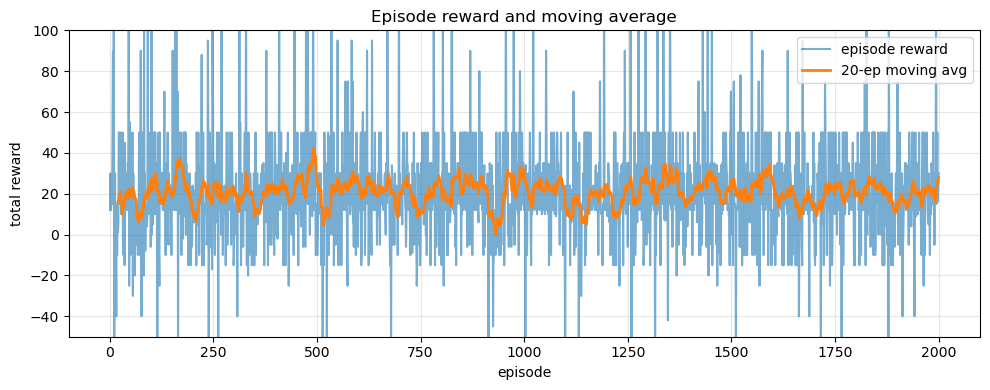

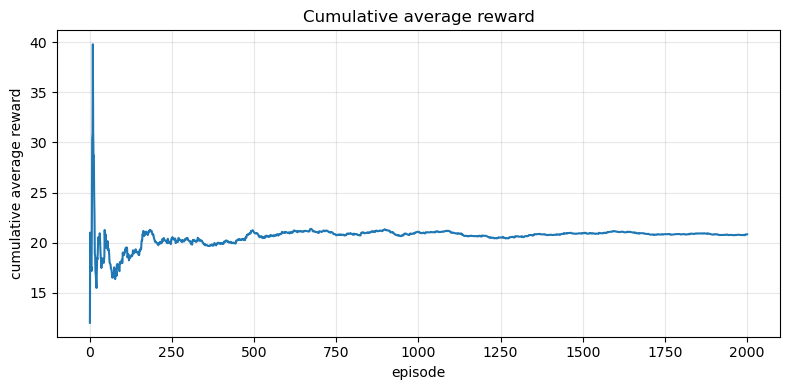

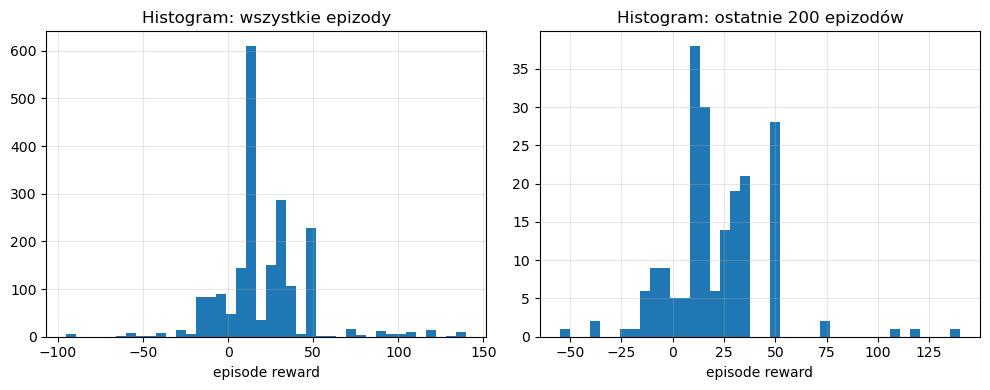


=== Q-table ===
     a0   a1    a2     a3
s1  5.2  6.9   2.2   -6.8
s2  5.3  7.4 -19.4 -169.7
s3  5.2  7.4  -4.2  -15.7
s4  7.2  6.7   6.5    4.0
s5  6.0  5.5   6.2    7.3
s6  3.8  7.3   5.2    6.5
s7  6.4  5.1   5.8    4.5

=== Policy (softmax probabilities, T=5) ===
      a0    a1    a2    a3
s1  0.33  0.46  0.18  0.03
s2  0.40  0.60  0.00  0.00
s3  0.37  0.57  0.06  0.01
s4  0.30  0.27  0.26  0.16
s5  0.24  0.21  0.24  0.30
s6  0.16  0.33  0.22  0.29
s7  0.30  0.23  0.27  0.21

=== SAMPLE TRAJECTORIES ANALYSIS ===
Total episodes: 2000


=== Trajectories statistics ===
trajectory  count  pct  mean_reward  var_reward  std_reward
1->3->7->1   1487 74.4         19.6       105.4        10.3
1->2->5->1    419 21.0         24.2      1152.4        33.9
1->3->6->1     94  4.7         21.0      2169.9        46.6


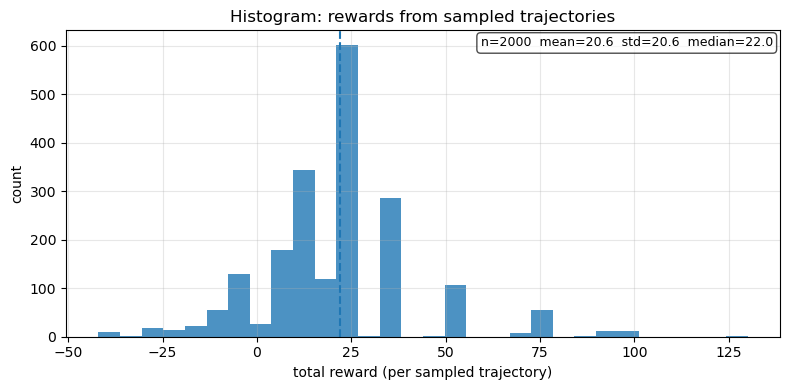

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETRY FINALNEGO TRENINGU ----------
final_seed = 555
final_num_episodes = 2000

eps_start = 0.5
eps_end = 0.05
eps_decay_frac = 0.5
optimistic_q = 5.0
min_alpha = 0.01
bonus_beta = 0

# risk-sensitive params
k1, l1 = 1.0, 0.5
k2, l2 = 1.0, 1.0
theta = 0.07
rs_mode = 'entropic_RA'           # wybierz 'u', 'entropic_RA', 'entropic_RS', 'neutral' 

env = step_low_variance

# polityka do symulacji i jej temperatura
policy_temperature = 5

# symulacja trajektorii
n_sample = 2000
max_steps = 50
start_state = 1
terminal_state = 1

# ---------- RUN: trening ----------
print("\n=== FINAL TRAINING ===")
q_final_risk, counts_final, ep_rewards_final = train_q_learning_risk(
    num_episodes=final_num_episodes,
    gamma=0.99,
    seed=final_seed,
    verbose_every=100,
    eps_start=eps_start,
    eps_end=eps_end,
    eps_decay_frac=eps_decay_frac,
    optimistic_q=optimistic_q,
    min_alpha=min_alpha,
    bonus_beta=bonus_beta,
    k1=k1, l1=l1, k2=k2, l2=l2, theta=theta,
    rs_mode=rs_mode
)

# ---------- PODSTAWOWE STATYSTYKI ----------
rewards = np.array(ep_rewards_final)

stats = {
    "n_episodes": len(rewards),
    "mean": round(float(np.mean(rewards)), 1),
    "median": round(float(np.median(rewards)), 1),
    "std": round(float(np.std(rewards)), 1),
    "min": round(float(np.min(rewards)), 1),
    "max": round(float(np.max(rewards)), 1)
}

print("\n=== TRAINING STATS ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\n=== FINAL Q ===")
# tylko do wyświetlenia; nie modyfikujemy q_final_risk używanego dalej (np. do softmax)
np.set_printoptions(precision=1, suppress=True)
print(np.round(q_final_risk, 1))

print("\n=== FINAL COUNTS ===")
print(counts_final)

# ---------- WYKRESY UCZENIA ----------
# 1) surowa krzywa reward per episode + moving average
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(ep_rewards_final)+1), ep_rewards_final, label='episode reward', alpha=0.6)
window = max(1, len(ep_rewards_final)//100)   # ~1% window
ma = np.convolve(ep_rewards_final, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window, len(ep_rewards_final)+1), ma, label=f'{window}-ep moving avg', linewidth=2)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Episode reward and moving average')
plt.legend()
plt.grid(alpha=0.3)

# ustaw zakres osi Y
plt.ylim(-50, 100)

plt.tight_layout()
plt.show()


# 2) cumulative average reward (jak szybko stabilizuje się polityka)
cumulative_avg = np.cumsum(ep_rewards_final) / (np.arange(len(ep_rewards_final)) + 1)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumulative_avg)+1), cumulative_avg)
plt.xlabel('episode')
plt.ylabel('cumulative average reward')
plt.title('Cumulative average reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) histogram rozkładu epizodowych nagród (ostatnie N i wszystkie)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(ep_rewards_final, bins=40)
plt.title('Histogram: wszystkie epizody')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
last_n = min(200, len(ep_rewards_final))
plt.hist(ep_rewards_final[-last_n:], bins=40)
plt.title(f'Histogram: ostatnie {last_n} epizodów')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Policy (softmax z Q/T) ---
def stable_softmax(arr, temp=1.0):
    z = arr / temp
    z = z - np.max(z)
    ex = np.exp(z)
    return ex / np.sum(ex)

policy_final = np.zeros_like(q_final_risk)
for s_idx in range(q_final_risk.shape[0]):
    policy_final[s_idx, :] = stable_softmax(q_final_risk[s_idx, :], temp=policy_temperature)

# --- Tabela Q-values (wyświetlone zaokrąglone do 1 miejsca po przecinku) ---
q_df = pd.DataFrame(
    q_final_risk,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print("\n=== Q-table ===")
print(q_df.round(1))

# --- Tabela Policy (softmax probabilities, tutaj do 2 miejsc po przecinku) ---
policy_df = pd.DataFrame(
    policy_final,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print(f"\n=== Policy (softmax probabilities, T={policy_temperature}) ===")
print(policy_df.round(2))

# ---------- GENEROWANIE I ANALIZA TRAJEKTORII ----------
rng = np.random.default_rng(final_seed + 134)

# Zaktualizowana funkcja: zwraca zarówno listę stanów, jak i sumaryczną nagrodę epizodu
def run_episode_with_policy(q_table, temperature, rng, start_state=1, terminal_state=1, max_steps=50):
    states = [start_state]
    state = start_state
    total_reward = 0.0
    for _ in range(max_steps):
        s_idx = S2I[state]
        probs = stable_softmax(q_table[s_idx, :], temperature)
        a_idx = int(rng.choice(len(probs), p=probs))
        action = ACTIONS[a_idx]
        next_state, reward = env(state, action)
        total_reward += reward
        states.append(next_state)
        state = next_state
        if state == terminal_state:
            break
    return states, total_reward

# --- Sampling: gromadzenie listy trajektorii i nagród dla każdej unikalnej trajektorii ---
traj_rewards = {}   # map: traj_tuple -> list of total rewards
traj_counts = Counter()
all_trajectories = []

for _ in range(n_sample):
    traj, ep_reward = run_episode_with_policy(q_final_risk, policy_temperature, rng,
                                              start_state=start_state,
                                              terminal_state=terminal_state,
                                              max_steps=max_steps)
    traj_t = tuple(traj)
    all_trajectories.append(traj)
    traj_counts[traj_t] += 1
    traj_rewards.setdefault(traj_t, []).append(ep_reward)

# --- Oblicz statystyki (count, pct, mean, var, std) dla każdej trajektorii ---
rows = []
for traj_t, rewards in traj_rewards.items():
    count = len(rewards)
    pct = 100.0 * count / n_sample
    mean = float(np.mean(rewards))
    var = float(np.var(rewards))
    std = float(np.std(rewards))
    # Do wyświetlenia: zaokrąglamy mean, var, std do 1 miejsca po przecinku
    rows.append({
        "trajectory": "->".join(map(str, traj_t)),
        "count": count,
        "pct": pct,
        "mean_reward": mean,
        "var_reward": var,
        "std_reward": std
    })

df_traj_stats = pd.DataFrame(rows)
df_traj_stats = df_traj_stats.sort_values(by="count", ascending=False).reset_index(drop=True)

# --- Wydrukuj wyróżnione trajektorie 1->2->4->1 oraz 1->3->7->1, jeśli wystąpiły ---
def print_traj_stats(df, traj_list):
    for t in traj_list:
        tstr = "->".join(map(str, t))
        row = df[df["trajectory"] == tstr]
        if not row.empty:
            r = row.iloc[0]
            # wyświetlane wartości zaokrąglone do 1 miejsca po przecinku
            print(f"{tstr} : count={int(r['count'])} ({r['pct']:.1f}%), mean={r['mean_reward']:.1f}, var={r['var_reward']:.1f}, std={r['std_reward']:.1f}")
        else:
            print(f"{tstr} : not observed")

print("\n=== SAMPLE TRAJECTORIES ANALYSIS ===")
print(f"Total episodes: {n_sample}\n")

# --- Top-10 najczęstszych trajektorii z ich statystykami ---
top_n = 10
# Przygotowanie do wyświetlenia: zaokrąglenie do 1 miejsca (oprócz count i pct)
df_display = df_traj_stats.copy()
df_display["mean_reward"] = df_display["mean_reward"].round(1)
df_display["var_reward"] = df_display["var_reward"].round(1)
df_display["std_reward"] = df_display["std_reward"].round(1)
df_display["pct"] = df_display["pct"].round(1)
print(f"\n=== Trajectories statistics ===")
print(df_display.head(top_n).to_string(index=False))

# --- Podsumowanie 'mixed' (czyli wszystkie trajektorie poza dwoma wyróżnionymi) ---
highlight_set = {"1->2->4->1", "1->3->7->1"}
mixed_df = df_traj_stats[~df_traj_stats["trajectory"].isin(highlight_set)]
mixed_total_count = mixed_df["count"].sum()
mixed_total_pct = 100.0 * mixed_total_count / n_sample
mixed_mean, mixed_std, mixed_var = (float(np.nan), float(np.nan), float(np.nan))
if mixed_total_count > 0:
    # obliczamy łączną średnią ważoną i wariancję całkowitą
    weighted_sum = (mixed_df["mean_reward"] * mixed_df["count"]).sum()
    mixed_mean = weighted_sum / mixed_total_count
    # dla wariancji: sum(var_i * n_i + n_i * mean_i^2) / N - mean_all^2
    sum_sq = ( (mixed_df["var_reward"] * mixed_df["count"]) + (mixed_df["mean_reward"]**2 * mixed_df["count"]) ).sum()
    mixed_var = (sum_sq / mixed_total_count) - (mixed_mean**2)
    mixed_std = float(np.sqrt(max(0.0, mixed_var)))

# spłaszczamy listy nagród dla wszystkich zsample'owanych trajektorii
sampled_rewards = [r for rewards in traj_rewards.values() for r in rewards]

# ---------- FINALNY HISTOGRAM: dodajemy medianę do adnotacji i pionową linię ----------
plt.figure(figsize=(8,4))
plt.hist(sampled_rewards, bins=30, alpha=0.8)
plt.xlabel("total reward (per sampled trajectory)")
plt.ylabel("count")
plt.title("Histogram: rewards from sampled trajectories")

# podstawowe statystyki
mean_sr = np.mean(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")
std_sr  = np.std(sampled_rewards)  if len(sampled_rewards) > 0 else float("nan")
median_sr = np.median(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")

# adnotacja: n, mean, std, median (mean/std zaokrąglone do 1 miejsca, median do 1 miejsca)
plt.annotate(f"n={len(sampled_rewards)}  mean={mean_sr:.1f}  std={std_sr:.1f}  median={median_sr:.1f}",
             xy=(0.99, 0.98), xycoords="axes fraction",
             va="top", ha="right", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# pionowa linia dla mediany
plt.axvline(median_sr, linestyle='--', linewidth=1.5)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== FINAL TRAINING ===

=== TRAINING STATS ===
n_episodes: 2000
mean: 21.1
median: 15.0
std: 40.4
min: -120.0
max: 200.0

=== FINAL Q ===
[[22.  29.7 56.2 56.6]
 [13.6 24.9 31.2 23.8]
 [10.2 20.5 20.2 -7.1]
 [35.  39.1 34.4 33.1]
 [12.8 13.8 12.9 12.9]
 [22.6 22.1 21.4 22.2]
 [ 9.2  9.6  9.9  9.6]]

=== FINAL COUNTS ===
[[ 44  44  63 116]
 [ 66  68 102 259]
 [ 51 232  52  51]
 [113 296 113 112]
 [153 132  67  67]
 [189  56  56  72]
 [116 157 127 174]]


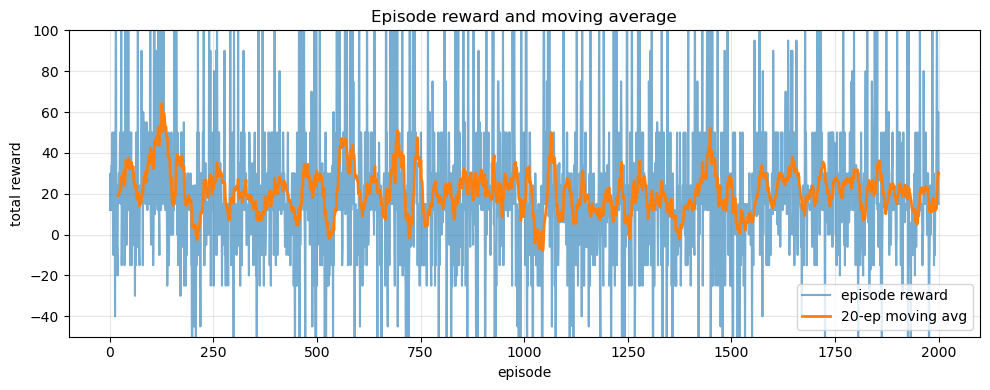

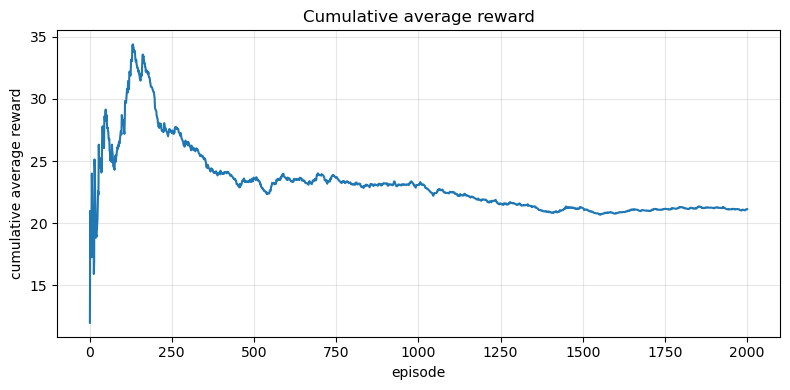

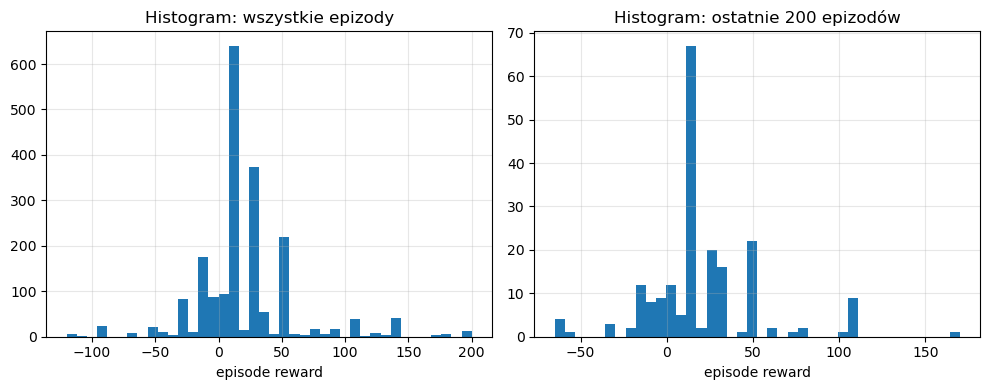


=== Q-table ===
      a0    a1    a2    a3
s1  22.0  29.7  56.2  56.6
s2  13.6  24.9  31.2  23.8
s3  10.2  20.5  20.2  -7.1
s4  35.0  39.1  34.4  33.1
s5  12.8  13.8  12.9  12.9
s6  22.6  22.1  21.4  22.2
s7   9.2   9.6   9.9   9.6

=== Policy (softmax probabilities, T=5) ===
      a0    a1    a2    a3
s1  0.00  0.00  0.48  0.52
s2  0.02  0.19  0.65  0.15
s3  0.06  0.48  0.45  0.00
s4  0.21  0.47  0.18  0.14
s5  0.23  0.29  0.24  0.24
s6  0.28  0.25  0.22  0.25
s7  0.23  0.25  0.27  0.25

=== SAMPLE TRAJECTORIES ANALYSIS ===
Total episodes: 2000


=== Trajectories statistics ===
trajectory  count  pct  mean_reward  var_reward  std_reward
1->2->4->1   1596 79.8         36.8      5666.0        75.3
1->2->5->1    396 19.8         27.6      1599.0        40.0
1->3->6->1      5  0.2         26.0      1024.0        32.0
1->3->7->1      3  0.2         26.7        27.6         5.2


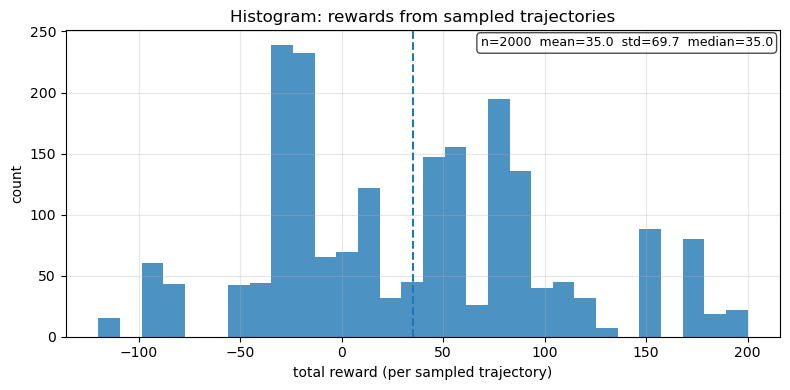

In [30]:
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETRY FINALNEGO TRENINGU ----------
final_seed = 555
final_num_episodes = 2000

eps_start = 0.5
eps_end = 0.05
eps_decay_frac = 0.5
optimistic_q = 5.0
min_alpha = 0.01
bonus_beta = 0

# risk-sensitive params
k1, l1 = 1.0, 0.5
k2, l2 = 1.0, 1.0
theta = 0.07
rs_mode = 'neutral'           # wybierz 'u', 'entropic_RA', 'entropic_RS', 'neutral' 

env = step_low_variance

# polityka do symulacji i jej temperatura
policy_temperature = 5

# symulacja trajektorii
n_sample = 2000
max_steps = 50
start_state = 1
terminal_state = 1

# ---------- RUN: trening ----------
print("\n=== FINAL TRAINING ===")
q_final_risk, counts_final, ep_rewards_final = train_q_learning_risk(
    num_episodes=final_num_episodes,
    gamma=0.99,
    seed=final_seed,
    verbose_every=100,
    eps_start=eps_start,
    eps_end=eps_end,
    eps_decay_frac=eps_decay_frac,
    optimistic_q=optimistic_q,
    min_alpha=min_alpha,
    bonus_beta=bonus_beta,
    k1=k1, l1=l1, k2=k2, l2=l2, theta=theta,
    rs_mode=rs_mode
)

# ---------- PODSTAWOWE STATYSTYKI ----------
rewards = np.array(ep_rewards_final)

stats = {
    "n_episodes": len(rewards),
    "mean": round(float(np.mean(rewards)), 1),
    "median": round(float(np.median(rewards)), 1),
    "std": round(float(np.std(rewards)), 1),
    "min": round(float(np.min(rewards)), 1),
    "max": round(float(np.max(rewards)), 1)
}

print("\n=== TRAINING STATS ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\n=== FINAL Q ===")
# tylko do wyświetlenia; nie modyfikujemy q_final_risk używanego dalej (np. do softmax)
np.set_printoptions(precision=1, suppress=True)
print(np.round(q_final_risk, 1))

print("\n=== FINAL COUNTS ===")
print(counts_final)

# ---------- WYKRESY UCZENIA ----------
# 1) surowa krzywa reward per episode + moving average
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(ep_rewards_final)+1), ep_rewards_final, label='episode reward', alpha=0.6)
window = max(1, len(ep_rewards_final)//100)   # ~1% window
ma = np.convolve(ep_rewards_final, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window, len(ep_rewards_final)+1), ma, label=f'{window}-ep moving avg', linewidth=2)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Episode reward and moving average')
plt.legend()
plt.grid(alpha=0.3)

# ustaw zakres osi Y
plt.ylim(-50, 100)

plt.tight_layout()
plt.show()


# 2) cumulative average reward (jak szybko stabilizuje się polityka)
cumulative_avg = np.cumsum(ep_rewards_final) / (np.arange(len(ep_rewards_final)) + 1)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumulative_avg)+1), cumulative_avg)
plt.xlabel('episode')
plt.ylabel('cumulative average reward')
plt.title('Cumulative average reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) histogram rozkładu epizodowych nagród (ostatnie N i wszystkie)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(ep_rewards_final, bins=40)
plt.title('Histogram: wszystkie epizody')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
last_n = min(200, len(ep_rewards_final))
plt.hist(ep_rewards_final[-last_n:], bins=40)
plt.title(f'Histogram: ostatnie {last_n} epizodów')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Policy (softmax z Q/T) ---
def stable_softmax(arr, temp=1.0):
    z = arr / temp
    z = z - np.max(z)
    ex = np.exp(z)
    return ex / np.sum(ex)

policy_final = np.zeros_like(q_final_risk)
for s_idx in range(q_final_risk.shape[0]):
    policy_final[s_idx, :] = stable_softmax(q_final_risk[s_idx, :], temp=policy_temperature)

# --- Tabela Q-values (wyświetlone zaokrąglone do 1 miejsca po przecinku) ---
q_df = pd.DataFrame(
    q_final_risk,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print("\n=== Q-table ===")
print(q_df.round(1))

# --- Tabela Policy (softmax probabilities, tutaj do 2 miejsc po przecinku) ---
policy_df = pd.DataFrame(
    policy_final,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print(f"\n=== Policy (softmax probabilities, T={policy_temperature}) ===")
print(policy_df.round(2))

# ---------- GENEROWANIE I ANALIZA TRAJEKTORII ----------
rng = np.random.default_rng(final_seed + 134)

# Zaktualizowana funkcja: zwraca zarówno listę stanów, jak i sumaryczną nagrodę epizodu
def run_episode_with_policy(q_table, temperature, rng, start_state=1, terminal_state=1, max_steps=50):
    states = [start_state]
    state = start_state
    total_reward = 0.0
    for _ in range(max_steps):
        s_idx = S2I[state]
        probs = stable_softmax(q_table[s_idx, :], temperature)
        a_idx = int(rng.choice(len(probs), p=probs))
        action = ACTIONS[a_idx]
        next_state, reward = env(state, action)
        total_reward += reward
        states.append(next_state)
        state = next_state
        if state == terminal_state:
            break
    return states, total_reward

# --- Sampling: gromadzenie listy trajektorii i nagród dla każdej unikalnej trajektorii ---
traj_rewards = {}   # map: traj_tuple -> list of total rewards
traj_counts = Counter()
all_trajectories = []

for _ in range(n_sample):
    traj, ep_reward = run_episode_with_policy(q_final_risk, policy_temperature, rng,
                                              start_state=start_state,
                                              terminal_state=terminal_state,
                                              max_steps=max_steps)
    traj_t = tuple(traj)
    all_trajectories.append(traj)
    traj_counts[traj_t] += 1
    traj_rewards.setdefault(traj_t, []).append(ep_reward)

# --- Oblicz statystyki (count, pct, mean, var, std) dla każdej trajektorii ---
rows = []
for traj_t, rewards in traj_rewards.items():
    count = len(rewards)
    pct = 100.0 * count / n_sample
    mean = float(np.mean(rewards))
    var = float(np.var(rewards))
    std = float(np.std(rewards))
    # Do wyświetlenia: zaokrąglamy mean, var, std do 1 miejsca po przecinku
    rows.append({
        "trajectory": "->".join(map(str, traj_t)),
        "count": count,
        "pct": pct,
        "mean_reward": mean,
        "var_reward": var,
        "std_reward": std
    })

df_traj_stats = pd.DataFrame(rows)
df_traj_stats = df_traj_stats.sort_values(by="count", ascending=False).reset_index(drop=True)

# --- Wydrukuj wyróżnione trajektorie 1->2->4->1 oraz 1->3->7->1, jeśli wystąpiły ---
def print_traj_stats(df, traj_list):
    for t in traj_list:
        tstr = "->".join(map(str, t))
        row = df[df["trajectory"] == tstr]
        if not row.empty:
            r = row.iloc[0]
            # wyświetlane wartości zaokrąglone do 1 miejsca po przecinku
            print(f"{tstr} : count={int(r['count'])} ({r['pct']:.1f}%), mean={r['mean_reward']:.1f}, var={r['var_reward']:.1f}, std={r['std_reward']:.1f}")
        else:
            print(f"{tstr} : not observed")

print("\n=== SAMPLE TRAJECTORIES ANALYSIS ===")
print(f"Total episodes: {n_sample}\n")

# --- Top-10 najczęstszych trajektorii z ich statystykami ---
top_n = 10
# Przygotowanie do wyświetlenia: zaokrąglenie do 1 miejsca (oprócz count i pct)
df_display = df_traj_stats.copy()
df_display["mean_reward"] = df_display["mean_reward"].round(1)
df_display["var_reward"] = df_display["var_reward"].round(1)
df_display["std_reward"] = df_display["std_reward"].round(1)
df_display["pct"] = df_display["pct"].round(1)
print(f"\n=== Trajectories statistics ===")
print(df_display.head(top_n).to_string(index=False))

# --- Podsumowanie 'mixed' (czyli wszystkie trajektorie poza dwoma wyróżnionymi) ---
highlight_set = {"1->2->4->1", "1->3->7->1"}
mixed_df = df_traj_stats[~df_traj_stats["trajectory"].isin(highlight_set)]
mixed_total_count = mixed_df["count"].sum()
mixed_total_pct = 100.0 * mixed_total_count / n_sample
mixed_mean, mixed_std, mixed_var = (float(np.nan), float(np.nan), float(np.nan))
if mixed_total_count > 0:
    # obliczamy łączną średnią ważoną i wariancję całkowitą
    weighted_sum = (mixed_df["mean_reward"] * mixed_df["count"]).sum()
    mixed_mean = weighted_sum / mixed_total_count
    # dla wariancji: sum(var_i * n_i + n_i * mean_i^2) / N - mean_all^2
    sum_sq = ( (mixed_df["var_reward"] * mixed_df["count"]) + (mixed_df["mean_reward"]**2 * mixed_df["count"]) ).sum()
    mixed_var = (sum_sq / mixed_total_count) - (mixed_mean**2)
    mixed_std = float(np.sqrt(max(0.0, mixed_var)))

# spłaszczamy listy nagród dla wszystkich zsample'owanych trajektorii
sampled_rewards = [r for rewards in traj_rewards.values() for r in rewards]

# ---------- FINALNY HISTOGRAM: dodajemy medianę do adnotacji i pionową linię ----------
plt.figure(figsize=(8,4))
plt.hist(sampled_rewards, bins=30, alpha=0.8)
plt.xlabel("total reward (per sampled trajectory)")
plt.ylabel("count")
plt.title("Histogram: rewards from sampled trajectories")

# podstawowe statystyki
mean_sr = np.mean(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")
std_sr  = np.std(sampled_rewards)  if len(sampled_rewards) > 0 else float("nan")
median_sr = np.median(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")

# adnotacja: n, mean, std, median (mean/std zaokrąglone do 1 miejsca, median do 1 miejsca)
plt.annotate(f"n={len(sampled_rewards)}  mean={mean_sr:.1f}  std={std_sr:.1f}  median={median_sr:.1f}",
             xy=(0.99, 0.98), xycoords="axes fraction",
             va="top", ha="right", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# pionowa linia dla mediany
plt.axvline(median_sr, linestyle='--', linewidth=1.5)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== FINAL TRAINING ===

=== TRAINING STATS ===
n_episodes: 2000
mean: 22.1
median: 15.0
std: 48.0
min: -120.0
max: 200.0

=== FINAL Q ===
[[9.6e+02 5.5e+27 3.4e+35 8.1e+35]
 [1.1e+01 1.5e+01 1.7e+02 1.2e+03]
 [9.9e+00 1.4e+01 1.0e+02 9.3e+02]
 [3.8e+01 3.8e+01 3.8e+01 4.4e+01]
 [1.2e+01 1.2e+01 1.4e+01 1.2e+01]
 [1.6e+01 2.0e+01 2.4e+01 1.9e+01]
 [1.3e+01 1.1e+01 9.4e+00 9.9e+00]]

=== FINAL COUNTS ===
[[ 36  36  36 195]
 [ 57  56  57 339]
 [ 39  39  38 216]
 [ 74  73  74 457]
 [ 44  44 261  44]
 [ 65  66 334  66]
 [272  41  43  42]]


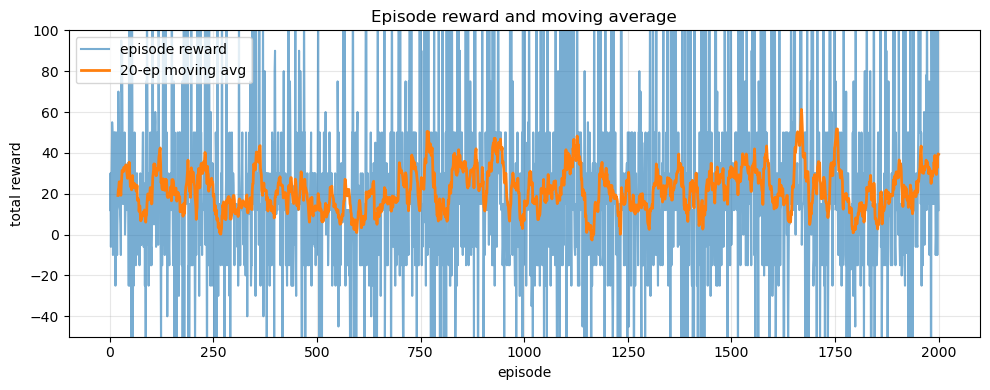

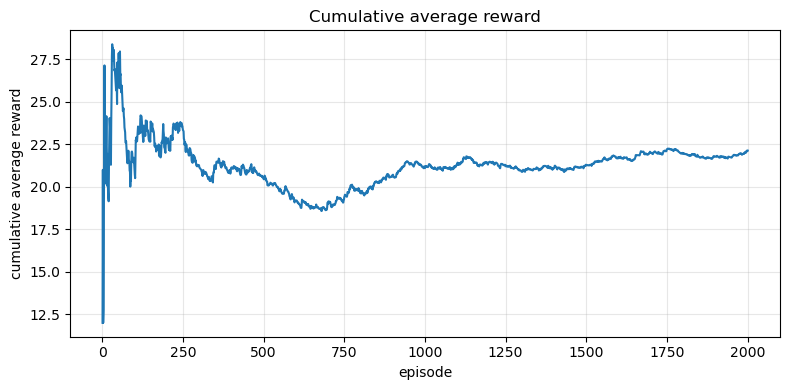

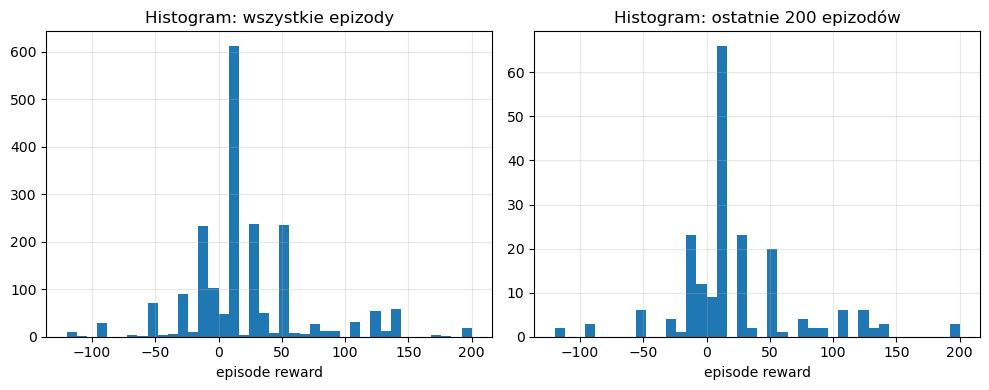


=== Q-table ===
       a0            a1            a2            a3
s1  960.3  5.515699e+27  3.387634e+35  8.125783e+35
s2   10.6  1.460000e+01  1.732000e+02  1.242400e+03
s3    9.9  1.440000e+01  1.042000e+02  9.289000e+02
s4   37.9  3.820000e+01  3.750000e+01  4.420000e+01
s5   11.7  1.180000e+01  1.440000e+01  1.170000e+01
s6   16.4  1.980000e+01  2.370000e+01  1.880000e+01
s7   12.9  1.060000e+01  9.400000e+00  9.900000e+00

=== Policy (softmax probabilities, T=5) ===
      a0    a1    a2    a3
s1  0.00  0.00  0.00  1.00
s2  0.00  0.00  0.00  1.00
s3  0.00  0.00  0.00  1.00
s4  0.15  0.16  0.14  0.54
s5  0.21  0.21  0.36  0.21
s6  0.11  0.22  0.48  0.18
s7  0.38  0.24  0.19  0.20

=== SAMPLE TRAJECTORIES ANALYSIS ===
Total episodes: 2000


=== Trajectories statistics ===
trajectory  count   pct  mean_reward  var_reward  std_reward
1->2->4->1   2000 100.0         32.4      9009.8        94.9


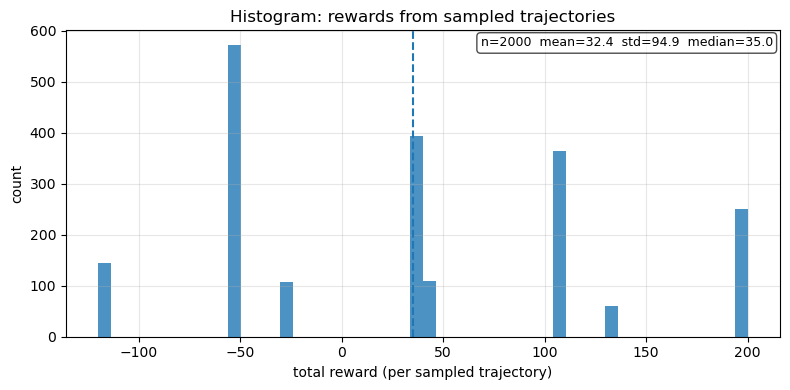

In [32]:
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETRY FINALNEGO TRENINGU ----------
final_seed = 555
final_num_episodes = 2000

eps_start = 0.5
eps_end = 0.05
eps_decay_frac = 0.5
optimistic_q = 5.0
min_alpha = 0.01
bonus_beta = 0

# risk-sensitive params
k1, l1 = 1.0, 0.5
k2, l2 = 1.0, 1.0
theta = 0.07
rs_mode = 'entropic_RS'           # wybierz 'u', 'entropic_RA', 'entropic_RS', 'neutral' 

env = step_low_variance

# polityka do symulacji i jej temperatura
policy_temperature = 5

# symulacja trajektorii
n_sample = 2000
max_steps = 50
start_state = 1
terminal_state = 1

# ---------- RUN: trening ----------
print("\n=== FINAL TRAINING ===")
q_final_risk, counts_final, ep_rewards_final = train_q_learning_risk(
    num_episodes=final_num_episodes,
    gamma=0.99,
    seed=final_seed,
    verbose_every=100,
    eps_start=eps_start,
    eps_end=eps_end,
    eps_decay_frac=eps_decay_frac,
    optimistic_q=optimistic_q,
    min_alpha=min_alpha,
    bonus_beta=bonus_beta,
    k1=k1, l1=l1, k2=k2, l2=l2, theta=theta,
    rs_mode=rs_mode
)

# ---------- PODSTAWOWE STATYSTYKI ----------
rewards = np.array(ep_rewards_final)

stats = {
    "n_episodes": len(rewards),
    "mean": round(float(np.mean(rewards)), 1),
    "median": round(float(np.median(rewards)), 1),
    "std": round(float(np.std(rewards)), 1),
    "min": round(float(np.min(rewards)), 1),
    "max": round(float(np.max(rewards)), 1)
}

print("\n=== TRAINING STATS ===")
for k, v in stats.items():
    print(f"{k}: {v}")

print("\n=== FINAL Q ===")
# tylko do wyświetlenia; nie modyfikujemy q_final_risk używanego dalej (np. do softmax)
np.set_printoptions(precision=1, suppress=True)
print(np.round(q_final_risk, 1))

print("\n=== FINAL COUNTS ===")
print(counts_final)

# ---------- WYKRESY UCZENIA ----------
# 1) surowa krzywa reward per episode + moving average
plt.figure(figsize=(10,4))
plt.plot(np.arange(1, len(ep_rewards_final)+1), ep_rewards_final, label='episode reward', alpha=0.6)
window = max(1, len(ep_rewards_final)//100)   # ~1% window
ma = np.convolve(ep_rewards_final, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window, len(ep_rewards_final)+1), ma, label=f'{window}-ep moving avg', linewidth=2)
plt.xlabel('episode')
plt.ylabel('total reward')
plt.title('Episode reward and moving average')
plt.legend()
plt.grid(alpha=0.3)

# ustaw zakres osi Y
plt.ylim(-50, 100)

plt.tight_layout()
plt.show()


# 2) cumulative average reward (jak szybko stabilizuje się polityka)
cumulative_avg = np.cumsum(ep_rewards_final) / (np.arange(len(ep_rewards_final)) + 1)
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumulative_avg)+1), cumulative_avg)
plt.xlabel('episode')
plt.ylabel('cumulative average reward')
plt.title('Cumulative average reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) histogram rozkładu epizodowych nagród (ostatnie N i wszystkie)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(ep_rewards_final, bins=40)
plt.title('Histogram: wszystkie epizody')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
last_n = min(200, len(ep_rewards_final))
plt.hist(ep_rewards_final[-last_n:], bins=40)
plt.title(f'Histogram: ostatnie {last_n} epizodów')
plt.xlabel('episode reward')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Policy (softmax z Q/T) ---
def stable_softmax(arr, temp=1.0):
    z = arr / temp
    z = z - np.max(z)
    ex = np.exp(z)
    return ex / np.sum(ex)

policy_final = np.zeros_like(q_final_risk)
for s_idx in range(q_final_risk.shape[0]):
    policy_final[s_idx, :] = stable_softmax(q_final_risk[s_idx, :], temp=policy_temperature)

# --- Tabela Q-values (wyświetlone zaokrąglone do 1 miejsca po przecinku) ---
q_df = pd.DataFrame(
    q_final_risk,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print("\n=== Q-table ===")
print(q_df.round(1))

# --- Tabela Policy (softmax probabilities, tutaj do 2 miejsc po przecinku) ---
policy_df = pd.DataFrame(
    policy_final,
    index=[f"s{int(s)}" for s in STATES],
    columns=[f"a{int(a)}" for a in ACTIONS]
)
print(f"\n=== Policy (softmax probabilities, T={policy_temperature}) ===")
print(policy_df.round(2))

# ---------- GENEROWANIE I ANALIZA TRAJEKTORII ----------
rng = np.random.default_rng(final_seed + 134)

# Zaktualizowana funkcja: zwraca zarówno listę stanów, jak i sumaryczną nagrodę epizodu
def run_episode_with_policy(q_table, temperature, rng, start_state=1, terminal_state=1, max_steps=50):
    states = [start_state]
    state = start_state
    total_reward = 0.0
    for _ in range(max_steps):
        s_idx = S2I[state]
        probs = stable_softmax(q_table[s_idx, :], temperature)
        a_idx = int(rng.choice(len(probs), p=probs))
        action = ACTIONS[a_idx]
        next_state, reward = env(state, action)
        total_reward += reward
        states.append(next_state)
        state = next_state
        if state == terminal_state:
            break
    return states, total_reward

# --- Sampling: gromadzenie listy trajektorii i nagród dla każdej unikalnej trajektorii ---
traj_rewards = {}   # map: traj_tuple -> list of total rewards
traj_counts = Counter()
all_trajectories = []

for _ in range(n_sample):
    traj, ep_reward = run_episode_with_policy(q_final_risk, policy_temperature, rng,
                                              start_state=start_state,
                                              terminal_state=terminal_state,
                                              max_steps=max_steps)
    traj_t = tuple(traj)
    all_trajectories.append(traj)
    traj_counts[traj_t] += 1
    traj_rewards.setdefault(traj_t, []).append(ep_reward)

# --- Oblicz statystyki (count, pct, mean, var, std) dla każdej trajektorii ---
rows = []
for traj_t, rewards in traj_rewards.items():
    count = len(rewards)
    pct = 100.0 * count / n_sample
    mean = float(np.mean(rewards))
    var = float(np.var(rewards))
    std = float(np.std(rewards))
    # Do wyświetlenia: zaokrąglamy mean, var, std do 1 miejsca po przecinku
    rows.append({
        "trajectory": "->".join(map(str, traj_t)),
        "count": count,
        "pct": pct,
        "mean_reward": mean,
        "var_reward": var,
        "std_reward": std
    })

df_traj_stats = pd.DataFrame(rows)
df_traj_stats = df_traj_stats.sort_values(by="count", ascending=False).reset_index(drop=True)

# --- Wydrukuj wyróżnione trajektorie 1->2->4->1 oraz 1->3->7->1, jeśli wystąpiły ---
def print_traj_stats(df, traj_list):
    for t in traj_list:
        tstr = "->".join(map(str, t))
        row = df[df["trajectory"] == tstr]
        if not row.empty:
            r = row.iloc[0]
            # wyświetlane wartości zaokrąglone do 1 miejsca po przecinku
            print(f"{tstr} : count={int(r['count'])} ({r['pct']:.1f}%), mean={r['mean_reward']:.1f}, var={r['var_reward']:.1f}, std={r['std_reward']:.1f}")
        else:
            print(f"{tstr} : not observed")

print("\n=== SAMPLE TRAJECTORIES ANALYSIS ===")
print(f"Total episodes: {n_sample}\n")

# --- Top-10 najczęstszych trajektorii z ich statystykami ---
top_n = 10
# Przygotowanie do wyświetlenia: zaokrąglenie do 1 miejsca (oprócz count i pct)
df_display = df_traj_stats.copy()
df_display["mean_reward"] = df_display["mean_reward"].round(1)
df_display["var_reward"] = df_display["var_reward"].round(1)
df_display["std_reward"] = df_display["std_reward"].round(1)
df_display["pct"] = df_display["pct"].round(1)
print(f"\n=== Trajectories statistics ===")
print(df_display.head(top_n).to_string(index=False))

# --- Podsumowanie 'mixed' (czyli wszystkie trajektorie poza dwoma wyróżnionymi) ---
highlight_set = {"1->2->4->1", "1->3->7->1"}
mixed_df = df_traj_stats[~df_traj_stats["trajectory"].isin(highlight_set)]
mixed_total_count = mixed_df["count"].sum()
mixed_total_pct = 100.0 * mixed_total_count / n_sample
mixed_mean, mixed_std, mixed_var = (float(np.nan), float(np.nan), float(np.nan))
if mixed_total_count > 0:
    # obliczamy łączną średnią ważoną i wariancję całkowitą
    weighted_sum = (mixed_df["mean_reward"] * mixed_df["count"]).sum()
    mixed_mean = weighted_sum / mixed_total_count
    # dla wariancji: sum(var_i * n_i + n_i * mean_i^2) / N - mean_all^2
    sum_sq = ( (mixed_df["var_reward"] * mixed_df["count"]) + (mixed_df["mean_reward"]**2 * mixed_df["count"]) ).sum()
    mixed_var = (sum_sq / mixed_total_count) - (mixed_mean**2)
    mixed_std = float(np.sqrt(max(0.0, mixed_var)))

# spłaszczamy listy nagród dla wszystkich zsample'owanych trajektorii
sampled_rewards = [r for rewards in traj_rewards.values() for r in rewards]

# ---------- FINALNY HISTOGRAM: dodajemy medianę do adnotacji i pionową linię ----------
plt.figure(figsize=(8,4))
plt.hist(sampled_rewards, bins=50, alpha=0.8)
plt.xlabel("total reward (per sampled trajectory)")
plt.ylabel("count")
plt.title("Histogram: rewards from sampled trajectories")

# podstawowe statystyki
mean_sr = np.mean(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")
std_sr  = np.std(sampled_rewards)  if len(sampled_rewards) > 0 else float("nan")
median_sr = np.median(sampled_rewards) if len(sampled_rewards) > 0 else float("nan")

# adnotacja: n, mean, std, median (mean/std zaokrąglone do 1 miejsca, median do 1 miejsca)
plt.annotate(f"n={len(sampled_rewards)}  mean={mean_sr:.1f}  std={std_sr:.1f}  median={median_sr:.1f}",
             xy=(0.99, 0.98), xycoords="axes fraction",
             va="top", ha="right", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# pionowa linia dla mediany
plt.axvline(median_sr, linestyle='--', linewidth=1.5)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
